# Preparation for interpolation

Confidence interval version

In [1]:
import sys
sys.path.append('../../Python_scripts')

## Import packages
from config import *
from support import *
from cosmo_support import *

/home/zhuge/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Preparation interpolation

search F range 

In [ ]:
sigma_rsl = 4000
Sigmas = np.linspace(0.01, 6.0, sigma_rsl)
# Sigmas = np.linspace(0.01, 8, sigma_rsl)
print([np.min(Sigmas), np.max(Sigmas)])

C0s = np.zeros_like(Sigmas)
As = np.zeros_like(Sigmas)
Errors = np.zeros_like(Sigmas)

pbar = tqdm(Sigmas)
for i, sigma in enumerate(pbar):
    pbar.set_description(f"Processing sigma={sigma:.4f}")
    
    C0 = find_C0_sigma(sigma,
                 condition='mean'
                  )
    C0s[i] = C0
    
    if C0==None:
        print(f"Warning: C0 is None for sigma={sigma:.4f}")
        A=None
        Errors[i] = None
    else:
        A = find_A_sigma(C_0=C0, sigma=sigma)
        As[i] = A
        
        def cdf(Delta):
            integral, _ = quad(lambda x: pdf_DM_cosmo(x, C_0=C0, A=A, sigma=sigma, alpha=3, beta=3), 1e-10, Delta)
            return integral
        
        sigma2=calc_confidence_interval_width(cdf=cdf, 
                                              target_prob= 0.6827 #0.9545 # 0.6827
                                              )
        
        """ sigma2=calc_confidence_interval_width(sigma=sigma, C_0=C0, A=A, 
                                              target_prob= 0.6827 #0.9545 # 0.6827
                                              ) """
        Errors[i] = sigma2/2  # Divide to get the width of the confidence interval 2*(0.6827: 1 sigma, 0.9545: 2 sigma)

[0.001, 6.0]


Processing sigma=0.7091:  12%|█▏        | 472/4000 [07:49<58:31,  1.00it/s]  


KeyboardInterrupt: 

In [ ]:
mask = ~pd.isnull(C0s) & ~pd.isnull(As) & ~pd.isnull(Errors)
C0s = C0s[mask]
As = As[mask]
Errors = Errors[mask]
Sigmas = Sigmas[mask]
print(len(Sigmas), len(C0s), len(As), len(Errors))

1000 1000 1000 1000


In [ ]:
# sigma_rsl=5000
# # Sigmas=np.linspace(sigma_min, sigma_max, sigma_rsl)
# Sigmas=np.linspace(0.1, 59.0, sigma_rsl)
# print([np.min(Sigmas),np.max(Sigmas)])
# C0s=np.zeros_like(Sigmas)
# As=np.zeros_like(Sigmas)
# Error_sqrt=np.zeros_like(Sigmas)
# for i, sigma in enumerate(Sigmas):
#     C0=C0_sigma(sigma)
#     C0s[i]=C0
#     A=find_A_sigma(C_0=C0, sigma=sigma)
#     As[i]=A
#     Error_sqrt[i]=np.sqrt(calculate_var(C0=C0, A=A, sigma_DM=sigma))

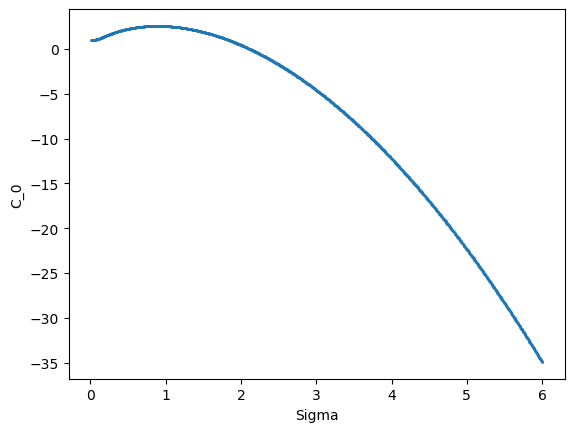

In [ ]:
plt.scatter(Sigmas, C0s,  s=1)

plt.ylabel('C_0')
plt.xlabel('Sigma')
# plt.xlim(0,10)

plt.show()

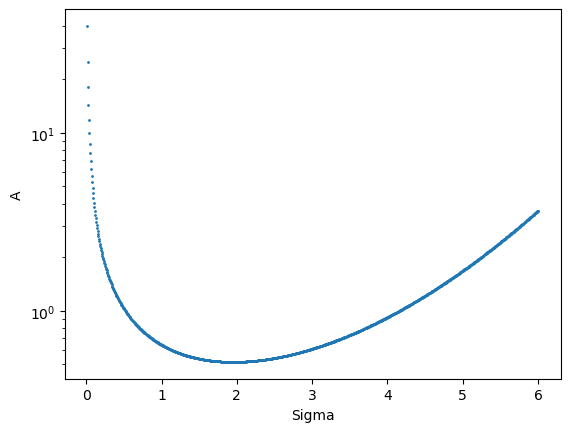

In [ ]:
plt.scatter(Sigmas, As,  s=1)

plt.ylabel('A')
plt.xlabel('Sigma')
plt.yscale('log')
# plt.xlim(0,10)

plt.show()

Text(0.5, 0, 'Error')

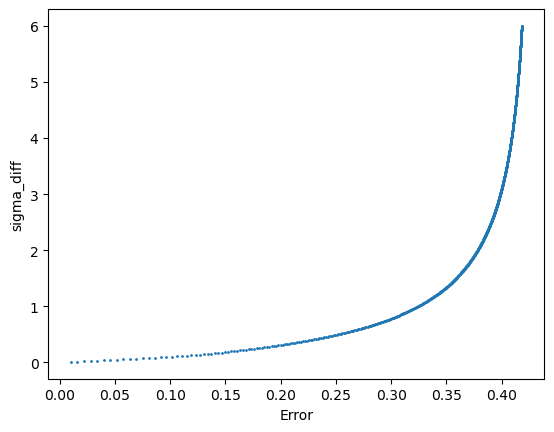

In [ ]:
plt.scatter(Errors, Sigmas,s=1)
plt.ylabel('sigma_diff')
plt.xlabel('Error')
# plt.xlim(0.7, 0.8)
# plt.xscale('log')
# plt.yscale('log')

Text(0.5, 0, 'Sigma')

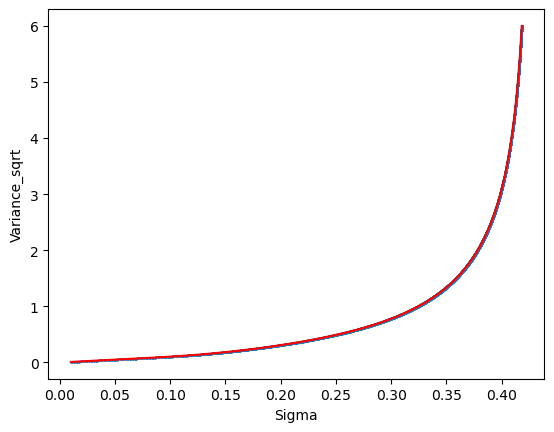

In [ ]:
inter_sigma=interpolate.interp1d(Sigmas, Errors, kind=1,bounds_error=False, 
    # fill_value='extrapolate'
    )
re_sigmas=np.linspace(np.min(Sigmas), np.max(Sigmas), 2*sigma_rsl)
re_var_sqrt=inter_sigma(re_sigmas)
plt.plot(re_var_sqrt, re_sigmas, 'r-', label='interpolated')
plt.scatter(Errors, Sigmas, s=1, label='original')
plt.ylabel('Variance_sqrt')
plt.xlabel('Sigma')

In [ ]:
np.savez('./interpolation/068_C0mean.npz', a=Sigmas, b=As, c=C0s, d=Errors)

In [ ]:
load_arrays=np.load('./interpolation/068_C0mean.npz')
Sigmas=load_arrays['a']
Errors=load_arrays['d']
C0s=load_arrays['c']
As=load_arrays['b']

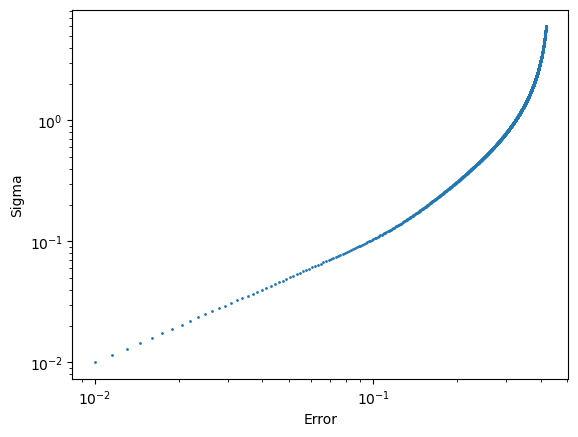

In [ ]:
plt.scatter(Errors, Sigmas, s=1)
plt.ylabel('Sigma')
plt.xlabel('Error')
plt.xscale('log')
plt.yscale('log')

0.10949313986032694
0.11634908727181796


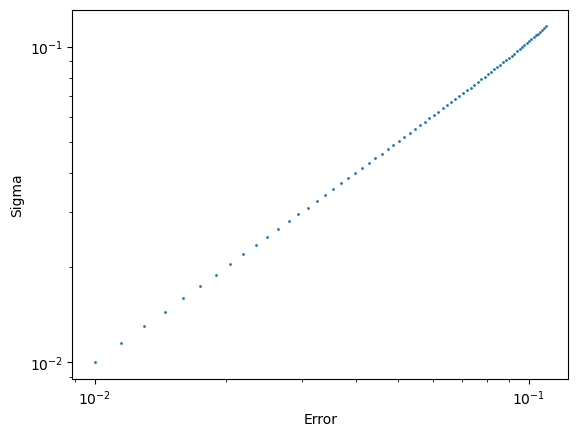

In [ ]:
th=0.11
fit_error=Errors[Errors<=th]
fit_Sigmas=Sigmas[Errors<=th]
print(max(fit_error))
print(max(fit_Sigmas))
plt.scatter(fit_error, fit_Sigmas, s=1)
plt.ylabel('Sigma')
plt.xlabel('Error')
plt.xscale('log')
plt.yscale('log')

In [ ]:
sigma=0.34
F=0.31
z=F/sigma
z=z**2
print(z)

0.8313148788927335


In [ ]:
log_errors=np.log10(fit_error)
log_Sigmas=np.log10(fit_Sigmas)

def fit_fun(x, b):
    return x+b

popt, pcov = curve_fit(fit_fun, log_errors, log_Sigmas)
print(popt)
b=popt[0]
c=10**b
print(c)

[0.00674075]
1.0156422192811811


In [ ]:
standard=np.sqrt(0.025)*c
print(np.sqrt(0.025+0.006)*c-standard)
print(standard)
print(standard-np.sqrt(0.025-0.008)*c)

0.018235130480691086
0.16058713503783567
0.02816359106257102


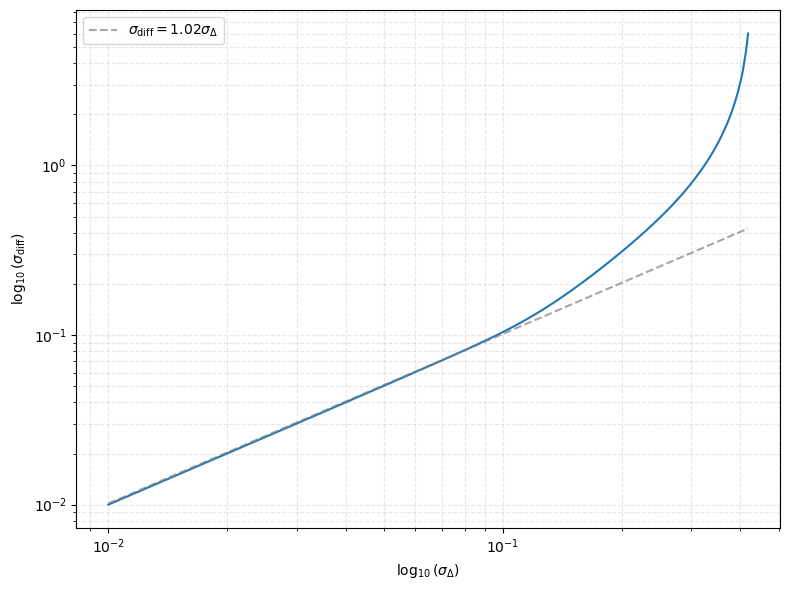

In [ ]:
plt.figure(figsize=(8, 6))
# plt.scatter(Errors, Sigmas,s=0.5)
plt.plot(Errors, Sigmas)
plt.ylabel(r'$\log_{10} (\sigma_{\rm diff})$')
plt.xlabel(r'$\log_{10} (\sigma_\Delta)$')
plt.xscale('log',base=10)
plt.yscale('log',base=10)

x_min = min(Errors)
x_max = max(Errors)
x_range = np.logspace(np.log10(x_min), np.log10(x_max), 100)

const=10**b
y_ref = x_range * const
plt.plot(x_range, y_ref, '--', color='gray', alpha=0.7, 
             label=r'$\sigma_{\rm diff} ='+f' {const:.2f}'+r'\sigma_\Delta $')

""" constants = [b-1, b-0.5, b, b+0.5, b+1]
for c in constants:
    const=(10**c)
    y_ref = x_range * const  # y = x * 10^c
    plt.plot(x_range, y_ref, '--', color='gray', alpha=0.7, 
             label=r'$\sigma_{\rm diff} ='+f' ({const:.2e})'+r'\sigma_\Delta $') """

plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('./plot/sigma_diff_vs_sigma_delta.pdf', dpi=300)

In [ ]:
# interpolation example

# C0_sigma = interpolate.interp1d(Sigmas, C0s, kind=1,bounds_error=False, 
#     # fill_value='extrapolate'
#     )

# A_sigma = interpolate.interp1d(Sigmas, As, kind=1,bounds_error=False, 
#     # fill_value='extrapolate'
#     )

# sigma_var = interpolate.interp1d(Error, Sigmas, kind=1,bounds_error=False, 
#     # fill_value='extrapolate'
#     )

In [ ]:
# np.save('./interpolation/Sigmas.npy', Sigmas)
# np.save('./interpolation/As.npy', As)
# np.save('./interpolation/C0s.npy', C0s)
# np.save('./interpolation/Errors.npy', Errors)